In [1]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
CACHE_DIR = PROJECT_ROOT / 'cache'
HF_CACHE_DIR = CACHE_DIR / 'huggingface'
HF_DATASETS_CACHE_DIR = HF_CACHE_DIR / 'datasets'
TRANSFORMERS_CACHE_DIR = CACHE_DIR / 'transformers'
KAGGLEHUB_CACHE_DIR = CACHE_DIR / 'kagglehub'
NLTK_DATA_DIR = CACHE_DIR / 'nltk_data'
TORCH_CACHE_DIR = CACHE_DIR / 'torch'
KERAS_CACHE_DIR = CACHE_DIR / 'keras'

for cache_path in [CACHE_DIR, HF_CACHE_DIR, HF_DATASETS_CACHE_DIR, TRANSFORMERS_CACHE_DIR, KAGGLEHUB_CACHE_DIR, NLTK_DATA_DIR, TORCH_CACHE_DIR, KERAS_CACHE_DIR]:
    cache_path.mkdir(parents=True, exist_ok=True)

os.environ['HF_HOME'] = str(HF_CACHE_DIR)
os.environ['HF_DATASETS_CACHE'] = str(HF_DATASETS_CACHE_DIR)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(HF_CACHE_DIR / 'hub')
os.environ['TRANSFORMERS_CACHE'] = str(TRANSFORMERS_CACHE_DIR)
os.environ['KAGGLEHUB_CACHE'] = str(KAGGLEHUB_CACHE_DIR)
os.environ['NLTK_DATA'] = str(NLTK_DATA_DIR)
os.environ['TORCH_HOME'] = str(TORCH_CACHE_DIR)
os.environ['KERAS_HOME'] = str(KERAS_CACHE_DIR)
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

import re
import json
import shutil
import joblib
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from datasets import load_dataset

print('Using project cache folder:', CACHE_DIR)


Using project cache folder: g:\College\semester 8\Foundation of Natural Language Processing\AI-vs-Human-Text-Detection\cache


In [2]:
local_path = Path('data/raw/essay/AI_Human.csv')
local_path.parent.mkdir(parents=True, exist_ok=True)

if local_path.exists():
    print('Loading dataset from local file:', local_path)
else:
    print('Local dataset not found. Downloading...')
    downloaded_path = Path(kagglehub.dataset_download('shanegerami/ai-vs-human-text'))
    source_path = downloaded_path / 'AI_Human.csv'
    if not source_path.exists():
        source_path = next(downloaded_path.rglob('AI_Human.csv'))
    shutil.copy(source_path, local_path)
    print('Dataset saved locally:', local_path)

Loading dataset from local file: data\raw\essay\AI_Human.csv


In [3]:
df = pd.read_csv(local_path)
df.head()

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  object 
 1   generated  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB


In [5]:
df.rename(columns={"generated": "source"}, inplace=True)

In [6]:
df['text'][0]

'Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.\n\nIn like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article

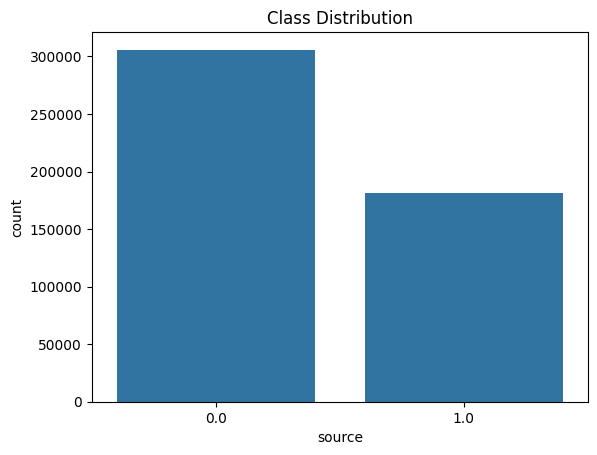

Class distribution summary:
Class 0.0: 305,797 samples (62.76%)
Class 1.0: 181,438 samples (37.24%)
Imbalance ratio (majority/minority): 1.69:1


In [7]:
sns.countplot(data=df, x='source')
plt.title('Class Distribution')
plt.show()

class_counts = df['source'].value_counts().sort_index()
class_percentages = (class_counts / class_counts.sum() * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

print('Class distribution summary:')
for label, count in class_counts.items():
    print(f'Class {label}: {count:,} samples ({class_percentages.loc[label]:.2f}%)')
print(f'Imbalance ratio (majority/minority): {imbalance_ratio:.2f}:1')


In [8]:
df['text'][0]

'Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.\n\nIn like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article

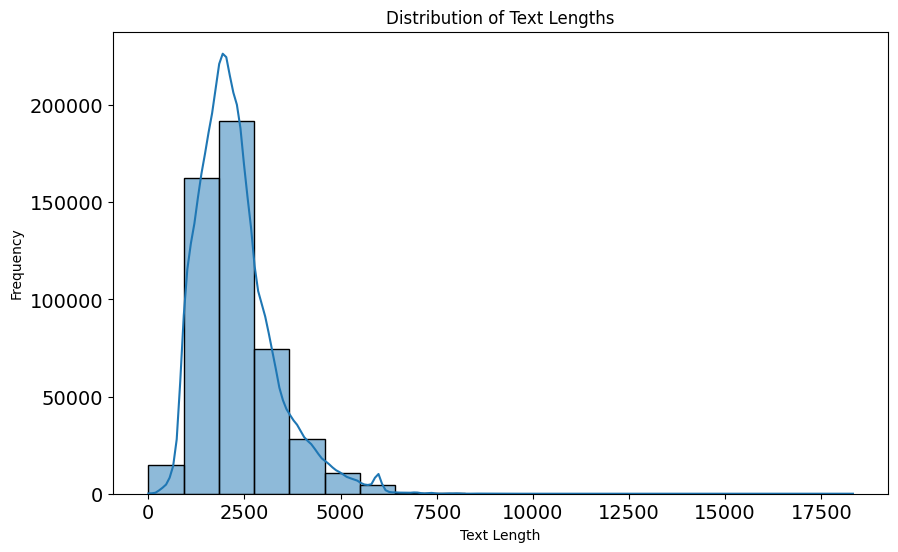

In [9]:
df['text_length'] = df['text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=20, kde=True)
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [10]:
df['text_length'].describe()

count    487235.000000
mean       2269.586592
std         988.814028
min           1.000000
25%        1583.000000
50%        2102.000000
75%        2724.000000
max       18322.000000
Name: text_length, dtype: float64

In [11]:
df = df.drop(columns=['text_length'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   text    487235 non-null  object 
 1   source  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB


In [13]:
df['text'][0]

'Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.\n\nIn like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article

In [14]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text)
    text = re.sub(r"[^a-z0-9\s\.,!\?;:'-]", ' ', text)
    text = re.sub(r'(.)\1{4,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [15]:
df = df.drop_duplicates(subset='text').dropna(subset=['text'])
df['cleaned_text'] = df['text'].apply(clean_text)
df['word_count'] = df['cleaned_text'].str.split().str.len()
df = df[(df['cleaned_text'] != '') & (df['word_count'] >= 50)]
df = df.drop_duplicates(subset='cleaned_text').reset_index(drop=True)

In [16]:
df[['text', 'cleaned_text', 'word_count']].head()

,text,cleaned_text,word_count
0,Cars. Cars have been around since they became ...,cars. cars have been around since they became ...,584
1,Transportation is a large necessity in most co...,transportation is a large necessity in most co...,462
2,"""America's love affair with it's vehicles seem...",america's love affair with it's vehicles seems...,750
3,How often do you ride in a car? Do you drive a...,how often do you ride in a car? do you drive a...,686
4,Cars are a wonderful thing. They are perhaps o...,cars are a wonderful thing. they are perhaps o...,871


In [17]:
df['cleaned_text'][0]

"cars. cars have been around since they became famous in the 1900s, when henry ford created and built the first modelt. cars have played a major role in our every day lives since then. but now, people are starting to question if limiting car usage would be a good thing. to me, limiting the use of cars might be a good thing to do. in like matter of this, article, in german suburb, life goes on without cars, by elizabeth rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either shanghai or chicago tend to make their homes. experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. passenger cars are responsible for 12 percent of greenhouse gas emissions in europe...and up to 50 percent in some carintensive areas in the united states. cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. article, par

In [18]:
df.head()

,text,source,cleaned_text,word_count
0,Cars. Cars have been around since they became ...,0.0,cars. cars have been around since they became ...,584
1,Transportation is a large necessity in most co...,0.0,transportation is a large necessity in most co...,462
2,"""America's love affair with it's vehicles seem...",0.0,america's love affair with it's vehicles seems...,750
3,How often do you ride in a car? Do you drive a...,0.0,how often do you ride in a car? do you drive a...,686
4,Cars are a wonderful thing. They are perhaps o...,0.0,cars are a wonderful thing. they are perhaps o...,871


In [20]:
top_words = Counter(" ".join(df[df['source'] == 0]['cleaned_text']).split()).most_common(10)
top_words

[('the', 5669880),
 ('to', 4126140),
 ('a', 2829698),
 ('and', 2715403),
 ('of', 2250242),
 ('in', 1955270),
 ('that', 1907082),
 ('is', 1749463),
 ('you', 1407519),
 ('it', 1355830)]

In [21]:
top_words = Counter(" ".join(df[df['source'] == 1]['cleaned_text']).split()).most_common(10)
top_words

[('the', 2607528),
 ('and', 2119590),
 ('to', 2113259),
 ('a', 1516363),
 ('of', 1499594),
 ('in', 1151594),
 ('that', 852517),
 ('is', 792956),
 ('for', 717239),
 ('can', 715593)]

In [22]:
import nltk
from nltk.tokenize import word_tokenize

nltk.data.path.insert(0, str(NLTK_DATA_DIR))
nltk.download('punkt', download_dir=str(NLTK_DATA_DIR))
nltk.download('punkt_tab', download_dir=str(NLTK_DATA_DIR), quiet=True)

df['tokenized_text'] = df['cleaned_text'].apply(word_tokenize)


[nltk_data] Downloading package punkt to g:\College\semester
[nltk_data]     8\Foundation of Natural Language Processing\AI-vs-
[nltk_data]     Human-Text-Detection\cache\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [23]:
df['viz_tokens'] = df['tokenized_text']


In [24]:
df['viz_tokens'][0]


['cars',
 '.',
 'cars',
 'have',
 'been',
 'around',
 'since',
 'they',
 'became',
 'famous',
 'in',
 'the',
 '1900s',
 ',',
 'when',
 'henry',
 'ford',
 'created',
 'and',
 'built',
 'the',
 'first',
 'modelt',
 '.',
 'cars',
 'have',
 'played',
 'a',
 'major',
 'role',
 'in',
 'our',
 'every',
 'day',
 'lives',
 'since',
 'then',
 '.',
 'but',
 'now',
 ',',
 'people',
 'are',
 'starting',
 'to',
 'question',
 'if',
 'limiting',
 'car',
 'usage',
 'would',
 'be',
 'a',
 'good',
 'thing',
 '.',
 'to',
 'me',
 ',',
 'limiting',
 'the',
 'use',
 'of',
 'cars',
 'might',
 'be',
 'a',
 'good',
 'thing',
 'to',
 'do',
 '.',
 'in',
 'like',
 'matter',
 'of',
 'this',
 ',',
 'article',
 ',',
 'in',
 'german',
 'suburb',
 ',',
 'life',
 'goes',
 'on',
 'without',
 'cars',
 ',',
 'by',
 'elizabeth',
 'rosenthal',
 'states',
 ',',
 'how',
 'automobiles',
 'are',
 'the',
 'linchpin',
 'of',
 'suburbs',
 ',',
 'where',
 'middle',
 'class',
 'families',
 'from',
 'either',
 'shanghai',
 'or',
 'chi

In [25]:
all_tokens = [token for tokens_list in df[df['source'] == 0]['viz_tokens'] for token in tokens_list]
Counter(all_tokens).most_common(10)


[('the', 5677313),
 ('.', 5670680),
 (',', 4505447),
 ('to', 4157008),
 ('a', 2834732),
 ('and', 2727400),
 ('of', 2259865),
 ('that', 2025806),
 ('in', 1984584),
 ('is', 1820501)]

In [26]:
all_tokens = [token for tokens_list in df[df['source'] == 1]['viz_tokens'] for token in tokens_list]
Counter(all_tokens).most_common(10)


[(',', 3709310),
 ('.', 3113556),
 ('the', 2608988),
 ('and', 2130629),
 ('to', 2119673),
 ('a', 1517433),
 ('of', 1502291),
 ('in', 1158561),
 ('that', 882936),
 ('is', 801747)]

In [27]:
df['tokenized_text'][0]

['cars',
 '.',
 'cars',
 'have',
 'been',
 'around',
 'since',
 'they',
 'became',
 'famous',
 'in',
 'the',
 '1900s',
 ',',
 'when',
 'henry',
 'ford',
 'created',
 'and',
 'built',
 'the',
 'first',
 'modelt',
 '.',
 'cars',
 'have',
 'played',
 'a',
 'major',
 'role',
 'in',
 'our',
 'every',
 'day',
 'lives',
 'since',
 'then',
 '.',
 'but',
 'now',
 ',',
 'people',
 'are',
 'starting',
 'to',
 'question',
 'if',
 'limiting',
 'car',
 'usage',
 'would',
 'be',
 'a',
 'good',
 'thing',
 '.',
 'to',
 'me',
 ',',
 'limiting',
 'the',
 'use',
 'of',
 'cars',
 'might',
 'be',
 'a',
 'good',
 'thing',
 'to',
 'do',
 '.',
 'in',
 'like',
 'matter',
 'of',
 'this',
 ',',
 'article',
 ',',
 'in',
 'german',
 'suburb',
 ',',
 'life',
 'goes',
 'on',
 'without',
 'cars',
 ',',
 'by',
 'elizabeth',
 'rosenthal',
 'states',
 ',',
 'how',
 'automobiles',
 'are',
 'the',
 'linchpin',
 'of',
 'suburbs',
 ',',
 'where',
 'middle',
 'class',
 'families',
 'from',
 'either',
 'shanghai',
 'or',
 'chi

In [28]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.data.path.insert(0, str(NLTK_DATA_DIR))
nltk.download('wordnet', download_dir=str(NLTK_DATA_DIR))
nltk.download('omw-1.4', download_dir=str(NLTK_DATA_DIR), quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized_text'] = df['tokenized_text'].apply(lemmatize_text)
df['processed_text'] = df['lemmatized_text'].apply(lambda tokens: ' '.join(tokens))


[nltk_data] Downloading package wordnet to g:\College\semester
[nltk_data]     8\Foundation of Natural Language Processing\AI-vs-
[nltk_data]     Human-Text-Detection\cache\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [29]:
all_tokens = [token for tokens_list in df[df['source'] == 0]['lemmatized_text'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[('the', 5677313),
 ('.', 5670680),
 (',', 4505447),
 ('to', 4157008),
 ('a', 3345971),
 ('and', 2727400),
 ('of', 2259865),
 ('that', 2025806),
 ('in', 1984892),
 ('is', 1820501)]

In [30]:
all_tokens = [token for tokens_list in df[df['source'] == 1]['lemmatized_text'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[(',', 3709310),
 ('.', 3113556),
 ('the', 2608988),
 ('and', 2130629),
 ('to', 2119673),
 ('a', 1904339),
 ('of', 1502291),
 ('in', 1158654),
 ('that', 882936),
 ('it', 809001)]

In [31]:
import gc

Path('data').mkdir(exist_ok=True)
MODEL_DATA_PATH = Path('data/essay_model.pkl')
modeling_df = df[['processed_text', 'source']].copy()
modeling_df['source'] = modeling_df['source'].astype('int8')
modeling_df.to_pickle(MODEL_DATA_PATH)

heavy_columns = ['text', 'word_count', 'tokenized_text', 'viz_tokens', 'lemmatized_text', 'cleaned_text']
df = modeling_df
for name in ['modeling_df', 'all_tokens']:
    if name in globals():
        del globals()[name]
gc.collect()

print(f'Saved compact modeling data to {MODEL_DATA_PATH}')
print('Current df columns:', df.columns.tolist())
print('Rows:', len(df))


Saved compact modeling data to data\essay_model.pkl
Current df columns: ['processed_text', 'source']
Rows: 464064


In [32]:
import gc

MODEL_DATA_PATH = Path('data/essay_model.pkl')
required_columns = {'processed_text', 'source'}

if 'df' in globals() and required_columns.issubset(df.columns):
    df = df[['processed_text', 'source']].copy()
    df['source'] = df['source'].astype('int8')
    print('Using existing in-memory compact df; no file was read.')
elif MODEL_DATA_PATH.exists():
    df = pd.read_pickle(MODEL_DATA_PATH)
    if not required_columns.issubset(df.columns):
        raise ValueError(
            f'{MODEL_DATA_PATH} does not contain processed_text. '
            'Run the preprocessing/save cell so tokenization and lemmatization are included.'
        )
    df = df[['processed_text', 'source']].copy()
    df['source'] = df['source'].astype('int8')
    print('Loaded compact modeling data from:', MODEL_DATA_PATH)
else:
    raise FileNotFoundError(
        f'{MODEL_DATA_PATH} does not exist. Run the preprocessing/save cell first. '
        'The old data/essay.pkl can be too large to load safely.'
    )

gc.collect()
print(df.info(memory_usage='deep'))


Using existing in-memory compact df; no file was read.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464064 entries, 0 to 464063
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   processed_text  464064 non-null  object
 1   source          464064 non-null  int8  
dtypes: int8(1), object(1)
memory usage: 1.0 GB
None


In [33]:
X = df['processed_text']
y = df['source']


In [34]:
X.head()

0    car . car have been around since they became f...
1    transportation is a large necessity in most co...
2    america 's love affair with it 's vehicle seem...
3    how often do you ride in a car ? do you drive ...
4    car are a wonderful thing . they are perhaps o...
Name: processed_text, dtype: object

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [36]:
print(len(X_train))
print(len(y_train))

324844
324844


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost.core import XGBoostError
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [38]:
def make_tfidf_pipeline(classifier, **tfidf_overrides):
    tfidf_params = {
        'ngram_range': (1, 2),
        'min_df': 2,
        'max_df': 0.95,
        'sublinear_tf': True,
        'dtype': np.float32
    }
    tfidf_params.update(tfidf_overrides)
    return Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('classifier', classifier)
    ])

pipelines = {
    'Naive Bayes': make_tfidf_pipeline(MultinomialNB()),
    'Logistic Regression': make_tfidf_pipeline(LogisticRegression(max_iter=1000, class_weight='balanced')),
    'Passive Aggressive': make_tfidf_pipeline(PassiveAggressiveClassifier(max_iter=1000, random_state=42, class_weight='balanced')),
    'Random Forest': make_tfidf_pipeline(
        RandomForestClassifier(
            n_estimators=50,
            max_depth=40,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42,
            class_weight='balanced'
        ),
        ngram_range=(1, 1),
        min_df=5,
        max_features=20000
    ),
    'XGBoost': make_tfidf_pipeline(
        XGBClassifier(
            booster='gblinear',
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=50,
            learning_rate=0.1,
            n_jobs=1,
            random_state=42
        ),
        ngram_range=(1, 1),
        min_df=10,
        max_features=10000
    )
}

ml_model_files = {
    'Naive Bayes': 'essay_naive_bayes.pkl',
    'Logistic Regression': 'essay_logistic_regression.pkl',
    'Passive Aggressive': 'essay_passive_aggressive.pkl',
    'Random Forest': 'essay_random_forest.pkl',
    'XGBoost': 'essay_xgboost.pkl'
}


In [39]:
ml_metrics = []
trained_ml_pipelines = {}
class_names = ['human', 'ai']

for model_name, pipeline in pipelines.items():
    try:
        pipeline.fit(X_train, y_train)
    except (MemoryError, XGBoostError) as exc:
        print(f'Skipping {model_name}: not enough memory to train this model on the current dataset.')
        print(exc)
        continue

    y_val_pred = pipeline.predict(X_val)
    y_test_pred = pipeline.predict(X_test)
    trained_ml_pipelines[model_name] = pipeline

    ml_metrics.append({
        'model': model_name,
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'val_precision': precision_score(y_val, y_val_pred, zero_division=0),
        'val_recall': recall_score(y_val, y_val_pred, zero_division=0),
        'val_f1': f1_score(y_val, y_val_pred, zero_division=0),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred, zero_division=0)
    })

    print(model_name)
    print('Validation')
    print('Confusion matrix:')
    print(confusion_matrix(y_val, y_val_pred, labels=[0, 1]))
    print(classification_report(y_val, y_val_pred, labels=[0, 1], target_names=class_names, zero_division=0))
    print('Final Test')
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_test_pred, labels=[0, 1]))
    print(classification_report(y_test, y_test_pred, labels=[0, 1], target_names=class_names, zero_division=0))


Naive Bayes
Validation
Confusion matrix:
[[42583    73]
 [ 1753 25201]]
              precision    recall  f1-score   support

       human       0.96      1.00      0.98     42656
          ai       1.00      0.93      0.97     26954

    accuracy                           0.97     69610
   macro avg       0.98      0.97      0.97     69610
weighted avg       0.97      0.97      0.97     69610

Final Test
Confusion matrix:
[[42584    73]
 [ 1737 25216]]
              precision    recall  f1-score   support

       human       0.96      1.00      0.98     42657
          ai       1.00      0.94      0.97     26953

    accuracy                           0.97     69610
   macro avg       0.98      0.97      0.97     69610
weighted avg       0.97      0.97      0.97     69610

Logistic Regression
Validation
Confusion matrix:
[[42619    37]
 [   89 26865]]
              precision    recall  f1-score   support

       human       1.00      1.00      1.00     42656
          ai       1.00  

In [40]:
ml_metrics_df = pd.DataFrame(ml_metrics).sort_values('val_f1', ascending=False)
ml_metrics_df

,model,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1
2,Passive Aggressive,0.999770,0.999740,0.999666,0.999703,0.999727,0.999703,0.999592,0.999648
4,XGBoost,0.999037,0.999406,0.998108,0.998756,0.998836,0.999034,0.997959,0.998497
1,Logistic Regression,0.998190,0.998625,0.996698,0.997660,0.997673,0.998400,0.995585,0.996991
3,Random Forest,0.996495,0.998358,0.992580,0.995461,0.996595,0.998656,0.992543,0.995590
0,Naive Bayes,0.973768,0.997112,0.934963,0.965038,0.973998,0.997113,0.935554,0.965354


In [41]:
model_dir = Path('models/essay/ml')
model_dir.mkdir(parents=True, exist_ok=True)

for model_name, pipeline in trained_ml_pipelines.items():
    joblib.dump(pipeline, model_dir / ml_model_files[model_name])

In [42]:
metrics_dir = Path('models/essay')
metrics_dir.mkdir(parents=True, exist_ok=True)

ml_metrics_df.to_csv(metrics_dir / 'essay_ml_metrics.csv', index=False)
with open(metrics_dir / 'essay_ml_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(ml_metrics, file, indent=2)

In [43]:
import gc

for name in [
    'nb_pipeline', 'logreg_pipeline', 'rf_pipeline', 'xgb_pipeline',
    'trained_ml_pipelines', 'pipelines', 'pipeline', 'X', 'y', 'X_train', 'X_temp', 'X_val', 'X_test',
    'y_train', 'y_temp', 'y_val', 'y_test', 'ml_metrics', 'ml_metrics_df', 'y_val_pred', 'y_test_pred'
]:
    if name in globals():
        del globals()[name]

gc.collect()
print('Released ML training objects from memory.')


Released ML training objects from memory.


The following section is designated for deep learning models.

In [44]:
print(type(df['processed_text'][0]))
print(df['processed_text'][0])

<class 'str'>
car . car have been around since they became famous in the 1900s , when henry ford created and built the first modelt . car have played a major role in our every day life since then . but now , people are starting to question if limiting car usage would be a good thing . to me , limiting the use of car might be a good thing to do . in like matter of this , article , in german suburb , life go on without car , by elizabeth rosenthal state , how automobile are the linchpin of suburb , where middle class family from either shanghai or chicago tend to make their home . expert say how this is a huge impediment to current effort to reduce greenhouse gas emission from tailpipe . passenger car are responsible for 12 percent of greenhouse gas emission in europe ... and up to 50 percent in some carintensive area in the united state . car are the main reason for the greenhouse gas emission because of a lot of people driving them around all the time getting where they need to go . ar

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import gc
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

texts = df['processed_text'].astype(str)
y = df['source'].astype('int8').values
max_vocab_size = 10000
max_len = int(np.percentile([len(text.split()) for text in texts], 95))
max_len = max(50, min(max_len, 500))

texts_train, texts_temp, y_train, y_temp = train_test_split(
    texts, y, test_size=0.3, random_state=42, stratify=y
)
texts_val, texts_test, y_val, y_test = train_test_split(
    texts_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Compute neural-network class weights from the training labels only to avoid data leakage.
dl_classes = np.unique(y_train)
dl_class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=dl_classes,
    y=y_train
)
dl_class_weights = torch.tensor(dl_class_weights_np, dtype=torch.float)
print('Deep learning class weights:', dict(zip(dl_classes.tolist(), dl_class_weights_np.round(4).tolist())))

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>', filters='', lower=False)
tokenizer.fit_on_texts(texts_train.tolist())

X_train = pad_sequences(tokenizer.texts_to_sequences(texts_train.tolist()), maxlen=max_len, padding='post', truncating='post')
X_val = pad_sequences(tokenizer.texts_to_sequences(texts_val.tolist()), maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(texts_test.tolist()), maxlen=max_len, padding='post', truncating='post')
del texts, texts_train, texts_temp, texts_val, texts_test, y_temp
gc.collect()

X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
del X_train, X_val, X_test
gc.collect()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

vocab_size = max_vocab_size + 1
label_mapping = {'human': 0, 'ai': 1}
print(f"Vocabulary size for embedding: {vocab_size}")
print(f"Sequence length: {max_len}")


Deep learning class weights: {0: 0.8159, 1: 1.2913}
Vocabulary size for embedding: 10001
Sequence length: 500


In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import RobertaModel

vocab_size = 29500  
embed_dim = 100    
hidden_dim=64                        

class DNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(DNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.global_avg_pool = lambda x: torch.mean(x, dim=1) 
        self.fc1 = nn.Linear(embed_dim, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)             
        x = self.global_avg_pool(x)       
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.output(x)
        return x




class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        self.output = nn.Linear(2 * hidden_dim, output_dim) 

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        x = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        x = self.output(x) 
        return x


class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv1d = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=5)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)  
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)  
        x = x.permute(0, 2, 1) 
        x = torch.relu(self.conv1d(x))
        x = self.global_max_pool(x).squeeze(-1)  
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, gru_hidden_dim, num_classes):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, gru_hidden_dim, batch_first=True) 
        self.fc1 = nn.Linear(gru_hidden_dim, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)                 
        _, hn = self.gru(x)                   
        x = hn[-1]                            
        x = torch.relu(self.fc1(x))           
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))           
        x = self.output(x)                    
        return x
    

g:\programs\Python\Python310\lib\site-packages\transformers\utils\hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelBinarizer

def evaluate_model(model, data_loader, device):
    model.eval()
    all_labels_list, all_preds_list, all_probs_raw_list = [], [], []

    num_classes = 0
    if hasattr(model, 'output'):
        num_classes = model.output.out_features
    elif hasattr(model, 'fc2'):
        num_classes = model.fc2.out_features
    elif hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        num_classes = model.fc.out_features
    else:
        raise AttributeError("Could not determine num_classes from model's output layer (expected 'output', 'fc2', or 'fc').")

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if labels.dim() == 2 and labels.size(1) == 1:
                labels = labels.squeeze(1)

            outputs = model(inputs)

            if num_classes > 1:
                probs = F.softmax(outputs, dim=1)
                all_probs_raw_list.extend(probs.cpu().numpy())
                
                _, preds = torch.max(outputs, 1)
                all_preds_list.extend(preds.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())
            else: 
                outputs_sigmoid = torch.sigmoid(outputs)
                probs = outputs_sigmoid.cpu().numpy()
                all_probs_raw_list.extend(probs.flatten()) 
                
                preds = (outputs_sigmoid >= 0.5).float().cpu().numpy()
                all_preds_list.extend(preds.flatten())
                all_labels_list.extend(labels.cpu().numpy().flatten())

    all_labels = np.array(all_labels_list).flatten().astype(int) 
    all_preds = np.array(all_preds_list).flatten().astype(int)

    if num_classes == 2:
        all_probs_for_auc = np.array(all_probs_raw_list) 
        if all_probs_for_auc.ndim == 2: 
            all_probs_for_auc = all_probs_for_auc[:, 1]
        elif all_probs_for_auc.ndim == 1 and np.unique(all_labels).size == 2: 
            pass 
        else:
            print("Warning: Unexpected shape for all_probs_raw_list in binary evaluation. Reshaping to 1D.")
            all_probs_for_auc = all_probs_for_auc.flatten()
            
    elif num_classes > 2:
        all_probs_for_auc = np.array(all_probs_raw_list) 
        if all_probs_for_auc.ndim == 1 and num_classes > 1: 
            print(f"Warning: all_probs_raw_list is 1D for multi-class {num_classes}. This is likely incorrect for AUC.")

            
    else: 
        all_probs_for_auc = np.array(all_probs_raw_list).flatten() 


    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    roc_auc = float('nan')
    if num_classes == 2:
        try:
            roc_auc = roc_auc_score(all_labels, all_probs_for_auc)
        except ValueError:
            roc_auc = 0.0
    elif num_classes > 2:
        if all_probs_for_auc.shape == (len(all_labels), num_classes):
            try:
                roc_auc = roc_auc_score(all_labels, all_probs_for_auc, multi_class='ovr', average='weighted')
            except ValueError:
                roc_auc = 0.0
        else:
            print(f"Warning: all_probs_for_auc shape {all_probs_for_auc.shape} mismatch with expected ({len(all_labels)}, {num_classes}) for multi-class AUC.")

    cm = confusion_matrix(all_labels, all_preds)

    print(f"Evaluation - Accuracy:  {accuracy:.4f}")
    print(f"Evaluation - Precision: {precision:.4f}")
    print(f"Evaluation - Recall:    {recall:.4f}")
    print(f"Evaluation - F1 Score:  {f1:.4f}")
    print("Classification report:")
    print(classification_report(all_labels, all_preds, labels=[0, 1], target_names=["human", "ai"], zero_division=0))
    if not np.isnan(roc_auc):
        print(f"Evaluation - AUC-ROC:   {roc_auc:.4f}")
    else:
        print("Evaluation - AUC-ROC:   Not applicable or calculation failed for AUC-ROC.")

    metrics = {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': None if np.isnan(roc_auc) else float(roc_auc)
    }

    return all_labels, all_probs_for_auc, cm, metrics


def plot_confusion_matrix(cm, labels=None):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


def plot_roc_curve(y_true, y_probs, num_classes, class_labels=None):
    y_true = np.array(y_true).flatten().astype(int)

    if num_classes == 2:
        if y_probs.ndim > 1 and y_probs.shape[1] == 2:
            y_probs = y_probs[:, 1]
        elif y_probs.ndim > 1 and y_probs.shape[1] == 1:
            y_probs = y_probs.flatten() 

        fpr, tpr, _ = roc_curve(y_true, y_probs)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    elif num_classes > 2:
        print("\nPlotting One-vs-Rest ROC Curves for multi-class.")
        plt.figure(figsize=(8, 7))
        
        lb = LabelBinarizer()
        y_true_bin = lb.fit_transform(y_true) 
        
        if y_probs.ndim != 2 or y_probs.shape[1] != num_classes:
             print(f"Warning: y_probs shape {y_probs.shape} is not (n_samples, {num_classes}) for multi-class One-vs-Rest ROC plotting. Skipping.")
             return

        for i in range(num_classes):
            if y_true_bin[:, i].sum() == 0 and y_probs[:, i].sum() == 0:
                continue

            try:
                fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
                class_roc_auc = auc(fpr, tpr)
            except ValueError as e:
                print(f"Could not plot ROC for class {i} ({class_labels[i] if class_labels else ''}): {e}")
                continue

            label_name = class_labels[i] if class_labels and i < len(class_labels) else f"Class {i}"
            plt.plot(fpr, tpr, label=f'{label_name} (AUC = {class_roc_auc:.2f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('One-vs-Rest ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    else:
        print(f"ROC Curve plotting is typically for binary or multi-class (One-vs-Rest). Your model has {num_classes} class(es).")


def train_model(model, train_loader, val_loader, test_loader, device, model_name="Model", epochs=5, class_weights=None):
    # Weighted loss reduces majority-class bias while keeping all original training examples.
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            if labels.dim() == 2 and labels.size(1) == 1:
                labels = labels.squeeze(1)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                if labels.dim() == 2 and labels.size(1) == 1:
                    labels = labels.squeeze(1)

                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)

                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        accuracy = correct / total
        val_accuracies.append(accuracy)
        print(f"{model_name} - Epoch {epoch+1}/{epochs}, Loss: {train_losses[-1]:.4f}, Val Accuracy: {accuracy:.4f}")

    print("\n--- Validation Evaluation ---")

    num_classes = 0
    if hasattr(model, 'output'):
        num_classes = model.output.out_features
    elif hasattr(model, 'fc2'):
        num_classes = model.fc2.out_features
    elif hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        num_classes = model.fc.out_features
    else:
        print("Warning: Could not determine num_classes from known output layer names. Defaulting to 2.")
        num_classes = 2

    if "y_val_tensor" in globals() and y_val_tensor is not None:
        unique_labels = sorted(y_val_tensor.unique().cpu().numpy())
        class_labels = [str(int(label)) for label in unique_labels]
    else:
        class_labels = [str(i) for i in range(num_classes)]

    val_metrics = {}
    test_metrics = {}

    try:
        actual_labels, predicted_probs, confusion_matrix_result, val_metrics = evaluate_model(model, val_loader, device)
        plot_confusion_matrix(confusion_matrix_result, labels=class_labels)
        plot_roc_curve(actual_labels, predicted_probs, num_classes=num_classes, class_labels=class_labels)
    except Exception as e:
        print(f"An error occurred during validation evaluation or plotting: {e}")

    print("\n--- Final Test Evaluation ---")
    try:
        actual_labels, predicted_probs, confusion_matrix_result, test_metrics = evaluate_model(model, test_loader, device)
        plot_confusion_matrix(confusion_matrix_result, labels=class_labels)
        plot_roc_curve(actual_labels, predicted_probs, num_classes=num_classes, class_labels=class_labels)
    except Exception as e:
        print(f"An error occurred during final test evaluation or plotting: {e}")

    return model, train_losses, val_accuracies, val_metrics, test_metrics


In [48]:
print(f"Max token in input: {X_train_tensor.max().item()}")
print(f"Vocab size: {vocab_size}")

Max token in input: 9999
Vocab size: 29500


In [49]:
print(torch.unique(y_train_tensor))
print(torch.unique(y_test_tensor))

tensor([0, 1])
tensor([0, 1])


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dl_class_weights = dl_class_weights.to(device)


TextCNN - Epoch 1/5, Loss: 0.0362, Val Accuracy: 0.9967
TextCNN - Epoch 2/5, Loss: 0.0102, Val Accuracy: 0.9993
TextCNN - Epoch 3/5, Loss: 0.0063, Val Accuracy: 0.9994
TextCNN - Epoch 4/5, Loss: 0.0050, Val Accuracy: 0.9992
TextCNN - Epoch 5/5, Loss: 0.0039, Val Accuracy: 0.9995

--- Validation Evaluation ---
Evaluation - Accuracy:  0.9995
Evaluation - Precision: 0.9995
Evaluation - Recall:    0.9995
Evaluation - F1 Score:  0.9995
Classification report:
              precision    recall  f1-score   support

       human       1.00      1.00      1.00     42656
          ai       1.00      1.00      1.00     26954

    accuracy                           1.00     69610
   macro avg       1.00      1.00      1.00     69610
weighted avg       1.00      1.00      1.00     69610

Evaluation - AUC-ROC:   1.0000


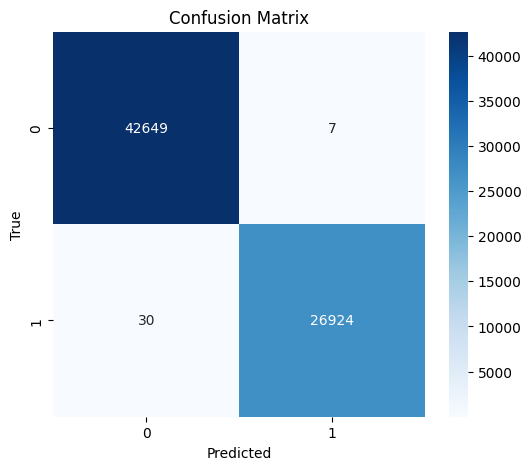

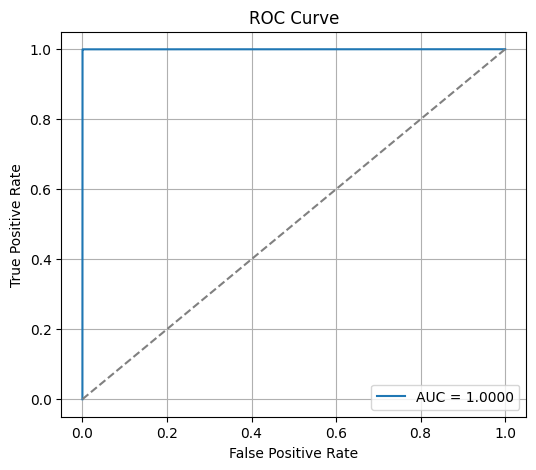


--- Final Test Evaluation ---
Evaluation - Accuracy:  0.9992
Evaluation - Precision: 0.9992
Evaluation - Recall:    0.9992
Evaluation - F1 Score:  0.9992
Classification report:
              precision    recall  f1-score   support

       human       1.00      1.00      1.00     42657
          ai       1.00      1.00      1.00     26953

    accuracy                           1.00     69610
   macro avg       1.00      1.00      1.00     69610
weighted avg       1.00      1.00      1.00     69610

Evaluation - AUC-ROC:   0.9999


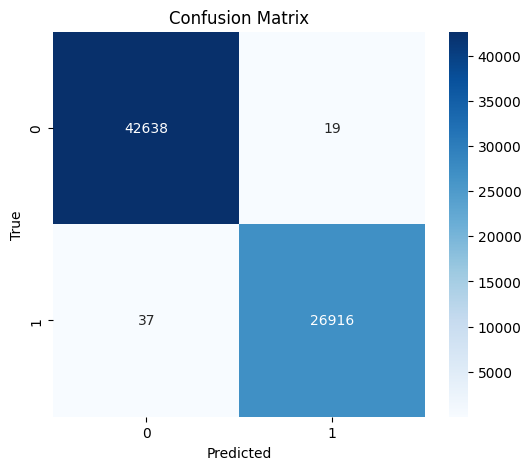

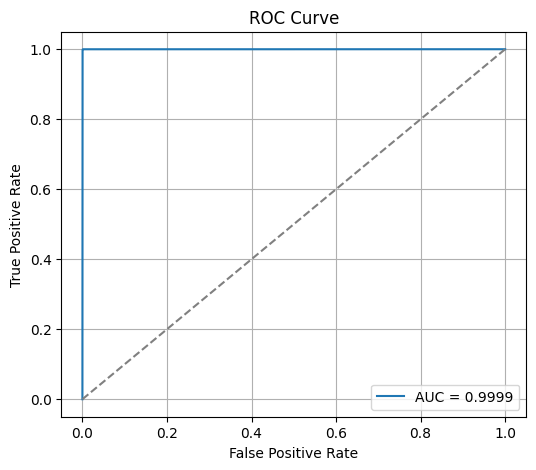

In [51]:
num_classes_CNN = df['source'].nunique()

cnn_model = CNNModel(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=num_classes_CNN
).to(device)
trained_cnn, cnn_losses, cnn_accs, cnn_val_metrics, cnn_test_metrics = train_model(
    cnn_model,
    train_loader,
    val_loader,
    test_loader,
    device,
    model_name='TextCNN',
    epochs=5,
    class_weights=dl_class_weights
)
dl_history = {'cnn': {'loss': cnn_losses, 'val_accuracy': cnn_accs, 'validation': cnn_val_metrics, 'test': cnn_test_metrics}}

In [52]:
dl_dir = Path('models/essay/dl')
dl_dir.mkdir(parents=True, exist_ok=True)
torch.save(trained_cnn.state_dict(), dl_dir / 'essay_cnn.pt')

BI-LSTM - Epoch 1/5, Loss: 0.0863, Val Accuracy: 0.9933
BI-LSTM - Epoch 2/5, Loss: 0.0146, Val Accuracy: 0.9981
BI-LSTM - Epoch 3/5, Loss: 0.0051, Val Accuracy: 0.9985
BI-LSTM - Epoch 4/5, Loss: 0.0027, Val Accuracy: 0.9988
BI-LSTM - Epoch 5/5, Loss: 0.0017, Val Accuracy: 0.9992

--- Validation Evaluation ---
Evaluation - Accuracy:  0.9992
Evaluation - Precision: 0.9992
Evaluation - Recall:    0.9992
Evaluation - F1 Score:  0.9992
Classification report:
              precision    recall  f1-score   support

       human       1.00      1.00      1.00     42656
          ai       1.00      1.00      1.00     26954

    accuracy                           1.00     69610
   macro avg       1.00      1.00      1.00     69610
weighted avg       1.00      1.00      1.00     69610

Evaluation - AUC-ROC:   1.0000


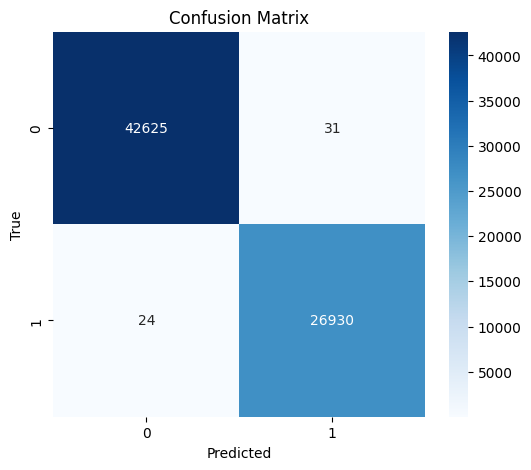

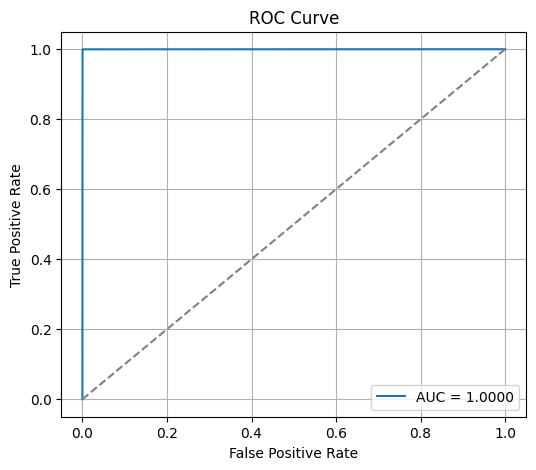


--- Final Test Evaluation ---
Evaluation - Accuracy:  0.9991
Evaluation - Precision: 0.9991
Evaluation - Recall:    0.9991
Evaluation - F1 Score:  0.9991
Classification report:
              precision    recall  f1-score   support

       human       1.00      1.00      1.00     42657
          ai       1.00      1.00      1.00     26953

    accuracy                           1.00     69610
   macro avg       1.00      1.00      1.00     69610
weighted avg       1.00      1.00      1.00     69610

Evaluation - AUC-ROC:   1.0000


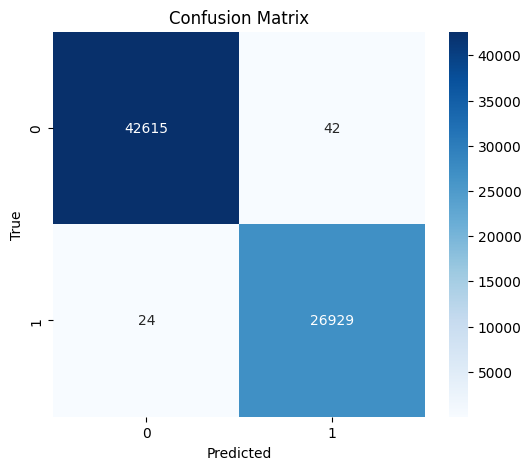

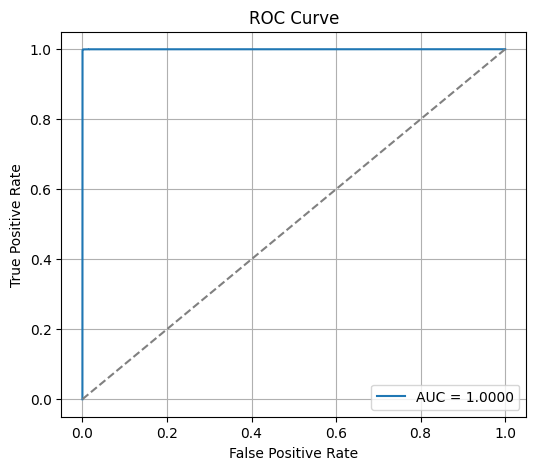

In [53]:
num_classes_BiLSTM = df['source'].nunique()
bilstm_model = BiLSTMModel(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=64,
    output_dim=num_classes_BiLSTM
).to(device)
trained_bilstm, bilstm_losses, bilstm_accs, bilstm_val_metrics, bilstm_test_metrics = train_model(
    bilstm_model, train_loader, val_loader, test_loader, device, model_name='BI-LSTM', epochs=5, class_weights=dl_class_weights
)
dl_history['bilstm'] = {'loss': bilstm_losses, 'val_accuracy': bilstm_accs, 'validation': bilstm_val_metrics, 'test': bilstm_test_metrics}

In [54]:
torch.save(trained_bilstm.state_dict(), dl_dir / 'essay_bilstm.pt')

GRU - Epoch 1/5, Loss: 0.0631, Val Accuracy: 0.9976
GRU - Epoch 2/5, Loss: 0.0068, Val Accuracy: 0.9987
GRU - Epoch 3/5, Loss: 0.0041, Val Accuracy: 0.9989
GRU - Epoch 4/5, Loss: 0.0037, Val Accuracy: 0.9992
GRU - Epoch 5/5, Loss: 0.0028, Val Accuracy: 0.9991

--- Validation Evaluation ---
Evaluation - Accuracy:  0.9991
Evaluation - Precision: 0.9991
Evaluation - Recall:    0.9991
Evaluation - F1 Score:  0.9991
Classification report:
              precision    recall  f1-score   support

       human       1.00      1.00      1.00     42656
          ai       1.00      1.00      1.00     26954

    accuracy                           1.00     69610
   macro avg       1.00      1.00      1.00     69610
weighted avg       1.00      1.00      1.00     69610

Evaluation - AUC-ROC:   1.0000


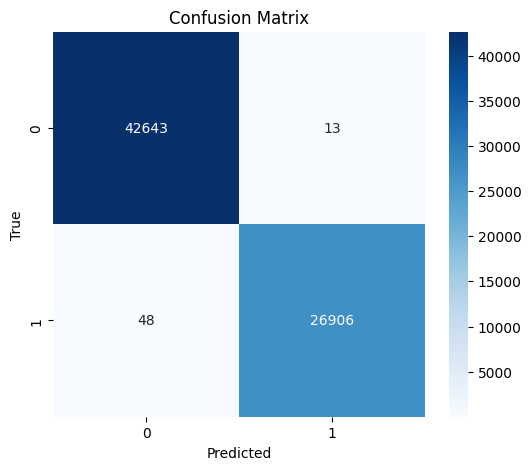

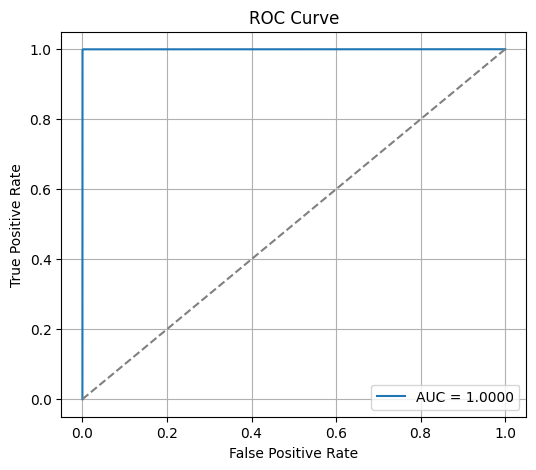


--- Final Test Evaluation ---
Evaluation - Accuracy:  0.9989
Evaluation - Precision: 0.9989
Evaluation - Recall:    0.9989
Evaluation - F1 Score:  0.9989
Classification report:
              precision    recall  f1-score   support

       human       1.00      1.00      1.00     42657
          ai       1.00      1.00      1.00     26953

    accuracy                           1.00     69610
   macro avg       1.00      1.00      1.00     69610
weighted avg       1.00      1.00      1.00     69610

Evaluation - AUC-ROC:   1.0000


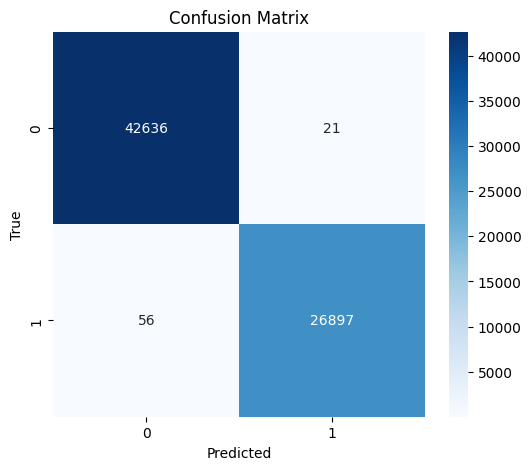

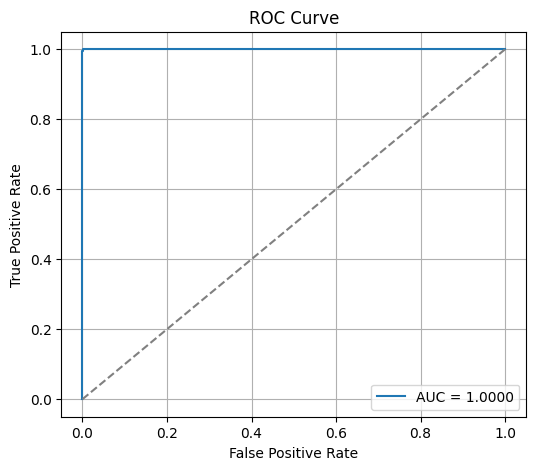

In [55]:
num_classes_GRU = df['source'].nunique()
gru_model = GRUModel(
    vocab_size=vocab_size,
    embed_dim=128,
    gru_hidden_dim=128,
    num_classes=num_classes_GRU
).to(device)
trained_gru, gru_losses, gru_accs, gru_val_metrics, gru_test_metrics = train_model(
    gru_model, train_loader, val_loader, test_loader, device, model_name='GRU', epochs=5, class_weights=dl_class_weights
)
dl_history['gru'] = {'loss': gru_losses, 'val_accuracy': gru_accs, 'validation': gru_val_metrics, 'test': gru_test_metrics}

In [56]:
torch.save(trained_gru.state_dict(), dl_dir / 'essay_gru.pt')

DNN - Epoch 1/5, Loss: 0.0507, Val Accuracy: 0.9960
DNN - Epoch 2/5, Loss: 0.0138, Val Accuracy: 0.9970
DNN - Epoch 3/5, Loss: 0.0080, Val Accuracy: 0.9978
DNN - Epoch 4/5, Loss: 0.0054, Val Accuracy: 0.9988
DNN - Epoch 5/5, Loss: 0.0041, Val Accuracy: 0.9982

--- Validation Evaluation ---
Evaluation - Accuracy:  0.9982
Evaluation - Precision: 0.9982
Evaluation - Recall:    0.9982
Evaluation - F1 Score:  0.9982
Classification report:
              precision    recall  f1-score   support

       human       1.00      1.00      1.00     42656
          ai       1.00      1.00      1.00     26954

    accuracy                           1.00     69610
   macro avg       1.00      1.00      1.00     69610
weighted avg       1.00      1.00      1.00     69610

Evaluation - AUC-ROC:   1.0000


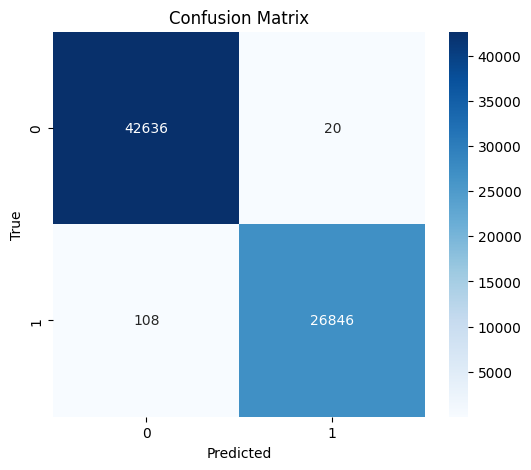

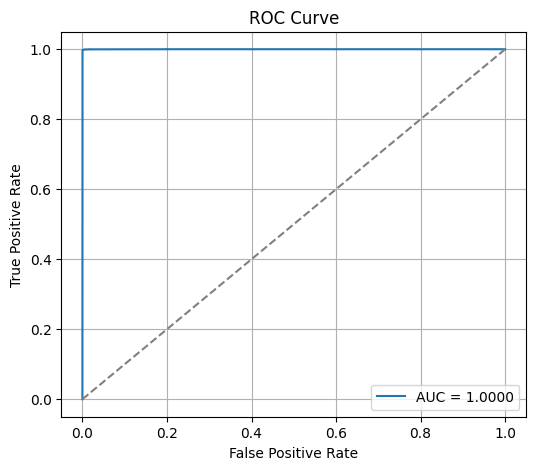


--- Final Test Evaluation ---
Evaluation - Accuracy:  0.9984
Evaluation - Precision: 0.9984
Evaluation - Recall:    0.9984
Evaluation - F1 Score:  0.9984
Classification report:
              precision    recall  f1-score   support

       human       1.00      1.00      1.00     42657
          ai       1.00      1.00      1.00     26953

    accuracy                           1.00     69610
   macro avg       1.00      1.00      1.00     69610
weighted avg       1.00      1.00      1.00     69610

Evaluation - AUC-ROC:   1.0000


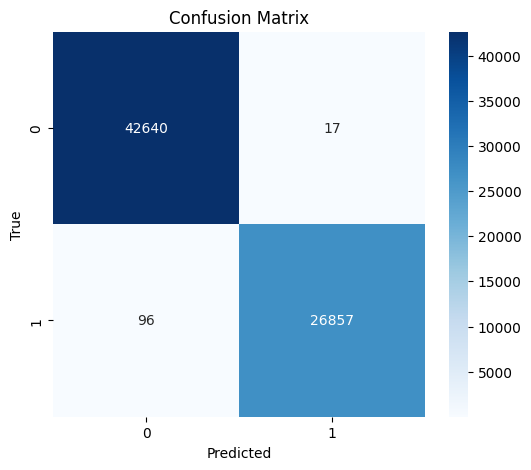

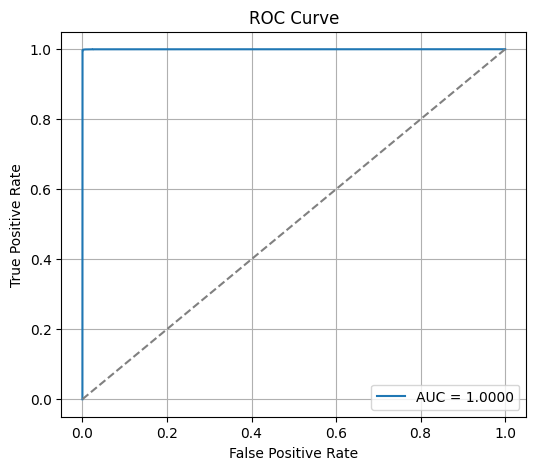

In [57]:
num_classes_DNN = df['source'].nunique()
dnn_model = DNNModel(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=num_classes_DNN
).to(device)
trained_dnn, dnn_losses, dnn_accs, dnn_val_metrics, dnn_test_metrics = train_model(
    dnn_model, train_loader, val_loader, test_loader, device, model_name='DNN', epochs=5, class_weights=dl_class_weights
)
dl_history['dnn'] = {'loss': dnn_losses, 'val_accuracy': dnn_accs, 'validation': dnn_val_metrics, 'test': dnn_test_metrics}

In [59]:
import gc

torch.save(trained_dnn.state_dict(), dl_dir / 'essay_dnn.pt')
joblib.dump(tokenizer, dl_dir / 'essay_tokenizer.pkl')

essay_dl_config = {
    'max_vocab_size': max_vocab_size,
    'vocab_size': vocab_size,
    'max_len': max_len,
    'padding': 'post',
    'truncating': 'post',
    'label_mapping': label_mapping,
    'preprocessing': 'processed_text',
    'split': {'train': 0.7, 'validation': 0.15, 'test': 0.15, 'stratified': True},
    'models': {
        'cnn': {'file': 'essay_cnn.pt', 'embed_dim': 128, 'num_classes': int(num_classes_CNN)},
        'bilstm': {'file': 'essay_bilstm.pt', 'embed_dim': 128, 'hidden_dim': 64, 'num_classes': int(num_classes_BiLSTM)},
        'gru': {'file': 'essay_gru.pt', 'embed_dim': 128, 'gru_hidden_dim': 128, 'num_classes': int(num_classes_GRU)},
        'dnn': {'file': 'essay_dnn.pt', 'embed_dim': 128, 'num_classes': int(num_classes_DNN)}
    }
}

with open(dl_dir / 'essay_dl_config.json', 'w', encoding='utf-8') as file:
    json.dump(essay_dl_config, file, indent=2)

pd.DataFrame([
    {
        'model': name,
        'final_loss': values['loss'][-1],
        'final_val_accuracy': values['val_accuracy'][-1],
        'val_f1': values['validation'].get('f1'),
        'test_f1': values['test'].get('f1'),
        'test_accuracy': values['test'].get('accuracy')
    }
    for name, values in dl_history.items()
]).to_csv(metrics_dir / 'essay_dl_metrics.csv', index=False)

with open(metrics_dir / 'essay_dl_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(dl_history, file, indent=2)

for name in [
    'trained_cnn', 'trained_bilstm', 'trained_gru', 'trained_dnn',
    'cnn_model', 'bilstm_model', 'gru_model', 'dnn_model',
    'train_loader', 'val_loader', 'test_loader', 'train_dataset', 'val_dataset', 'test_dataset',
    'X_train_tensor', 'X_val_tensor', 'X_test_tensor', 'y_train_tensor', 'y_val_tensor', 'y_test_tensor',
    'cnn_losses', 'cnn_accs', 'cnn_val_metrics', 'cnn_test_metrics',
    'bilstm_losses', 'bilstm_accs', 'bilstm_val_metrics', 'bilstm_test_metrics',
    'gru_losses', 'gru_accs', 'gru_val_metrics', 'gru_test_metrics',
    'dnn_losses', 'dnn_accs', 'dnn_val_metrics', 'dnn_test_metrics'
]:
    if name in globals():
        del globals()[name]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print('Saved DL artifacts and released DL training objects from memory.')


Saved DL artifacts and released DL training objects from memory.


In [58]:
import gc

MODEL_DATA_PATH = Path('data/essay_model.pkl')
required_columns = {'processed_text', 'source'}

if 'df' in globals() and required_columns.issubset(df.columns):
    df = df[['processed_text', 'source']].copy()
    df['source'] = df['source'].astype('int8')
    print('Using existing in-memory compact df for transformers; no file was read.')
elif MODEL_DATA_PATH.exists():
    df = pd.read_pickle(MODEL_DATA_PATH)
    if not required_columns.issubset(df.columns):
        raise ValueError(
            f'{MODEL_DATA_PATH} does not contain processed_text. '
            'Run the preprocessing/save cell so tokenization and lemmatization are included.'
        )
    df = df[['processed_text', 'source']].copy()
    df['source'] = df['source'].astype('int8')
    print('Loaded compact modeling data from:', MODEL_DATA_PATH)
else:
    raise FileNotFoundError(
        f'{MODEL_DATA_PATH} does not exist. Run the preprocessing/save cell first. '
        'The old data/essay.pkl can be too large to load safely.'
    )

gc.collect()


Using existing in-memory compact df for transformers; no file was read.


55422

In [60]:
df.head()

,processed_text,source
0,car . car have been around since they became f...,0
1,transportation is a large necessity in most co...,0
2,america 's love affair with it 's vehicle seem...,0
3,how often do you ride in a car ? do you drive ...,0
4,car are a wonderful thing . they are perhaps o...,0


In [60]:
from transformers import RobertaTokenizer
from TransformersTraining import build_roberta, train_Transformers
from sklearn.utils.class_weight import compute_class_weight

transformer_dir = Path('models/essay/transformers')
transformer_dir.mkdir(parents=True, exist_ok=True)
transformer_df = df[['processed_text', 'source']].rename(columns={'processed_text': 'cleaned_text'})
train_df, temp_df = train_test_split(
    transformer_df, test_size=0.3, random_state=42, stratify=transformer_df['source']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['source']
)

# Compute transformer class weights from the transformer training labels only.
transformer_classes = np.unique(train_df['source'].astype('int8').values)
transformer_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=transformer_classes,
    y=train_df['source'].astype('int8').values
)
print('Transformer class weights:', dict(zip(transformer_classes.tolist(), transformer_class_weights.round(4).tolist())))


Epoch 1:   5%|▍         | 999/20303 [18:05<6:05:27,  1.14s/it, loss=0.274]  


Saved checkpoint at iter 1000: models\essay\transformers\roberta\ckpt_iter1000.pt


Epoch 1:   5%|▍         | 1000/20303 [20:40<254:22:02, 47.44s/it, loss=0.274, avg_train_loss=0.297, val_loss=0.0945]


Saved improved checkpoint: models\essay\transformers\roberta\best_iter1000_val_0.0945.pt


Epoch 1:  10%|▉         | 1999/20303 [38:48<5:46:24,  1.14s/it, loss=0.0286]                                        

...


Saved checkpoint at iter 59000: models\essay\transformers\roberta\ckpt_iter59000.pt


Epoch 3:  96%|█████████▌| 19393/20303 [3:07:41<06:48,  2.23it/s, loss=0.114]                                           


Saved checkpoint at iter 60000: models\essay\transformers\roberta\ckpt_iter60000.pt


Epoch 3: 100%|██████████| 20303/20303 [3:16:48<00:00,  1.72it/s, loss=0.0776]                                        


Epoch 3 validation loss: 0.1026


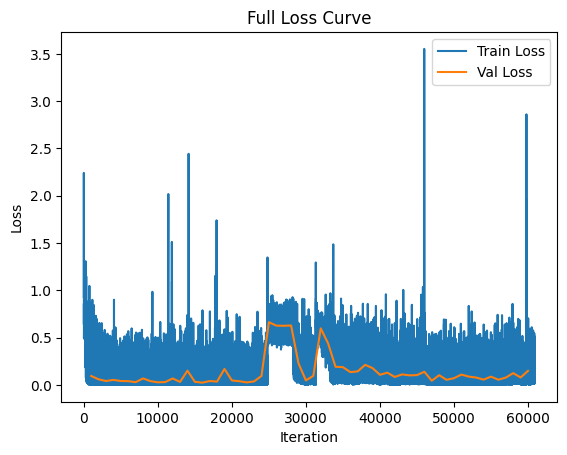

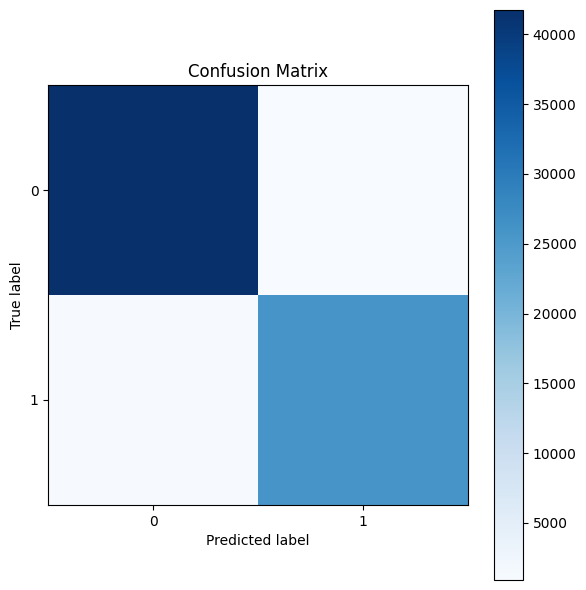

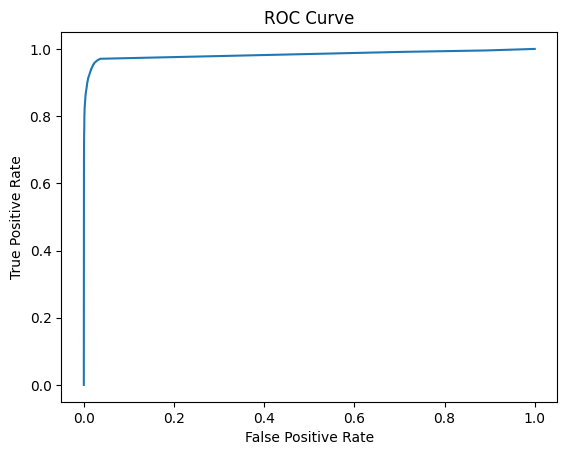

Released RoBERTa objects from memory.


In [61]:
roberta = build_roberta()
roberta_tokenizer = RobertaTokenizer.from_pretrained(
    'roberta-base',
    cache_dir=str(TRANSFORMERS_CACHE_DIR)
)
train_Transformers(
    roberta,
    roberta_tokenizer,
    train_df,
    val_df,
    lr=2e-5,
    weight_decay=0.01,
    epochs=3,
    loss_check=1000,
    checkpoint_dir=transformer_dir / 'roberta',
    class_weights=transformer_class_weights
)

del roberta, roberta_tokenizer, train_df, val_df, test_df, transformer_class_weights
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print('Released RoBERTa objects from memory.')
